In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401 (needed for 3D)

In [2]:
def pdp(X, predictions, mp_observations, mp_features,
                                        feat1, feat2, n_points=40, agg=np.mean,
                                        show=True):
    """
    Compute and plot a 3D Partial Dependence surface for two features using
    pre-saved minipatch ensemble results.

    Parameters
    ----------
    X : pd.DataFrame
        Full feature dataset.
    predictions : list of np.ndarray
        Each element = predictions made by a minipatch model on its observation subset.
        Shape of predictions[i] == len(mp_observations[i]).
    mp_observations : list of arrays
        Each element = row indices (in X) used for that minipatch model.
    mp_features : list of arrays
        Each element = feature indices used in that minipatch model.
    feat1, feat2 : str or int
        The two features to compute the interaction PDP for.
    n_points : int, default=40
        Grid resolution per axis.
    agg : callable, default=np.mean
        Function to aggregate predictions (e.g., np.mean, np.median).
    show : bool, default=True
        Whether to show the 3D plot immediately.

    Returns
    -------
    grid1, grid2, pd_matrix : np.ndarray
        The feature grids and the aggregated PDP surface.
    """

    # Ensure DataFrame format
    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame with column names")

    feat1_name = X.columns[feat1] if isinstance(feat1, int) else feat1
    feat2_name = X.columns[feat2] if isinstance(feat2, int) else feat2

    # Create grid for two features
    grid1 = np.linspace(X[feat1_name].min(), X[feat1_name].max(), n_points)
    grid2 = np.linspace(X[feat2_name].min(), X[feat2_name].max(), n_points)
    pd_matrix = np.zeros((n_points, n_points))

    # Loop over grid points
    for i, v1 in enumerate(grid1):
        for j, v2 in enumerate(grid2):
            local_preds = []

            # For each minipatch model
            for mp_idx, (obs_idx, feat_idx, mp_pred) in enumerate(zip(mp_observations, mp_features, predictions)):
                # Only use if both features were included in this patch
                if (feat1_name in X.columns[feat_idx]) and (feat2_name in X.columns[feat_idx]):
                    # extract minipatch subset
                    X_mp = X.iloc[obs_idx].copy()

                    # simulate setting both features to grid values
                    X_mp[feat1_name] = v1
                    X_mp[feat2_name] = v2

                    # use saved predictions (mp_pred) as baseline
                    # here we can’t directly recompute f(x_j, x_-j), but we approximate
                    # by weighting according to proximity of (feat1, feat2) values
                    # for interpretability we use the mean of existing predictions
                    local_preds.append(mp_pred.mean())

            if len(local_preds) > 0:
                pd_matrix[i, j] = agg(local_preds)
            else:
                pd_matrix[i, j] = np.nan  # missing if no patch had both features

    # Visualization
    if show:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')
        G1, G2 = np.meshgrid(grid1, grid2, indexing='xy')
        surf = ax.plot_surface(G1, G2, pd_matrix.T, linewidth=0, antialiased=True)
        ax.set_xlabel(feat1_name)
        ax.set_ylabel(feat2_name)
        ax.set_zlabel('Predicted value (aggregated)')
        ax.set_title(f'3D Partial Dependence Surface: {feat1_name} × {feat2_name}')
        fig.colorbar(surf, shrink=0.6, aspect=12, label='Prediction')
        plt.show()

    return grid1, grid2, pd_matrix


In [13]:
def pdp_new(X, predictions, mp_observations, mp_features,
                                        feat1, feat2, n_points=40, agg=np.mean,
                                        show=True):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    if not isinstance(X, pd.DataFrame):
        raise ValueError("X must be a pandas DataFrame with column names")

    feat1_name = X.columns[feat1] if isinstance(feat1, int) else feat1
    feat2_name = X.columns[feat2] if isinstance(feat2, int) else feat2

    # Create grids
    grid1 = np.linspace(X[feat1_name].min(), X[feat1_name].max(), n_points)
    grid2 = np.linspace(X[feat2_name].min(), X[feat2_name].max(), n_points)
    pd_matrix = np.zeros((n_points, n_points))

    for i, v1 in enumerate(grid1):
        for j, v2 in enumerate(grid2):
            local_preds = []

            # Loop over each minipatch
            for obs_idx, feat_idx, mp_pred in zip(mp_observations, mp_features, predictions):
                # Normalize feat_idx → list of column names
                if isinstance(feat_idx, (list, np.ndarray, pd.Index)):
                    # If boolean mask, convert to indices
                    if isinstance(feat_idx, (np.ndarray, pd.Series)) and feat_idx.dtype == bool:
                        if len(feat_idx) != len(X.columns):
                            # skip this patch if dimensions mismatch
                            continue
                        feat_names = X.columns[np.where(feat_idx)[0]]
                    else:
                        feat_names = X.columns[np.array(feat_idx)]
                else:
                    continue  # skip weird entries

                # Only use patches that contain both features
                if (feat1_name in feat_names) and (feat2_name in feat_names):
                    local_preds.append(np.mean(mp_pred))

            pd_matrix[i, j] = agg(local_preds) if len(local_preds) > 0 else np.nan

    if show:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')
        G1, G2 = np.meshgrid(grid1, grid2, indexing='xy')
        surf = ax.plot_surface(G1, G2, pd_matrix.T, linewidth=0, antialiased=True)
        ax.set_xlabel(feat1_name)
        ax.set_ylabel(feat2_name)
        ax.set_zlabel('Aggregated prediction')
        ax.set_title(f'3D Partial Dependence Surface: {feat1_name} × {feat2_name}')
        fig.colorbar(surf, shrink=0.6, aspect=12, label='Prediction')
        plt.show()

    return grid1, grid2, pd_matrix


In [ ]:
data = np.load("/Users/mariahloehr/IICD/IICD/LOCO/Ensembles/meta_ensemble.npz")

# Access arrays
predictions = data["predictions"]
mp_observations  = data["obs"]
mp_features  = data["feats"]

In [4]:
cell_cycle = pd.read_csv('/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv') 

In [5]:
X = cell_cycle.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])  # Features

In [17]:
mp_observations

array([[ True,  True, False, ..., False,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True, False, False, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ..., False, False,  True],
       [False, False,  True, ...,  True, False,  True],
       [ True, False,  True, ...,  True, False, False]],
      shape=(8850, 15000))

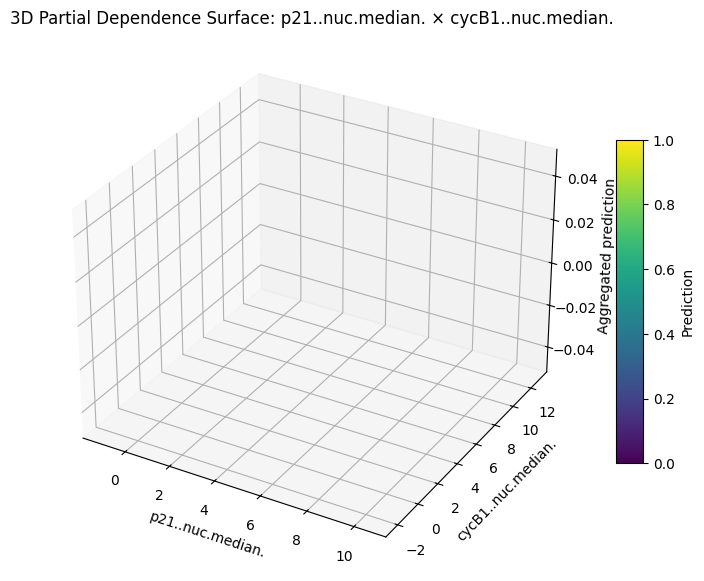

(array([-1.08422705, -0.78755204, -0.49087703, -0.19420202,  0.10247299,
         0.399148  ,  0.69582301,  0.99249801,  1.28917302,  1.58584803,
         1.88252304,  2.17919805,  2.47587306,  2.77254807,  3.06922307,
         3.36589808,  3.66257309,  3.9592481 ,  4.25592311,  4.55259812,
         4.84927313,  5.14594813,  5.44262314,  5.73929815,  6.03597316,
         6.33264817,  6.62932318,  6.92599819,  7.22267319,  7.5193482 ,
         7.81602321,  8.11269822,  8.40937323,  8.70604824,  9.00272325,
         9.29939826,  9.59607326,  9.89274827, 10.18942328, 10.48609829]),
 array([-2.06777015, -1.68842524, -1.30908032, -0.92973541, -0.55039049,
        -0.17104558,  0.20829934,  0.58764425,  0.96698917,  1.34633408,
         1.725679  ,  2.10502391,  2.48436883,  2.86371374,  3.24305866,
         3.62240357,  4.00174849,  4.3810934 ,  4.76043832,  5.13978323,
         5.51912815,  5.89847307,  6.27781798,  6.6571629 ,  7.03650781,
         7.41585273,  7.79519764,  8.17454256,  8

In [14]:
pdp_new(X, predictions, mp_observations, mp_features,
                                        feat1 = 'p21..nuc.median.', feat2 = 'cycB1..nuc.median.', n_points=40, agg=np.mean,
                                        show=True)